# Введение

Ссылка на датасет:
- https://www.kaggle.com/datasets/sagarmorework/adidas-us-sales

Анализ данных о продажах является ключевым аспектом для оптимизации бизнес-процессов и повышения эффективности ритейл-компаний, таких как Adidas, в условиях высокой конкуренции на рынке спортивных товаров. Точный прогноз объемов продаж и операционной прибыли позволяет компаниям эффективно управлять запасами, планировать маркетинговые стратегии и оптимизировать каналы сбыта, что снижает издержки и повышает прибыльность.

В последние годы машинное обучение зарекомендовало себя как мощный инструмент для анализа больших объемов данных и прогнозирования бизнес-показателей, включая объемы продаж и операционную прибыль.

Целью данной исследовательской работы является разработка и оценка моделей машинного обучения для предсказания объемов продаж и операционной прибыли компании Adidas на основе данных о продажах в США, включающих информацию о ритейлерах, регионах, продуктах и методах продаж.



In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

In [5]:
sns.set(style="ticks")

In [9]:
data = pd.read_csv('Adidas US Sales.csv', sep=';')

In [10]:
print('Размер датасета:', data.shape)
print('\nТипы данных:')
print(data.dtypes)
print('\nПропуски:')
print(data.isnull().sum())
print('\nОписательная статистика:')
print(data.describe())

Размер датасета: (9637, 13)

Типы данных:
sales_id             int64
retailer            object
retailer_id          int64
invoice_date        object
region              object
state               object
city                object
product             object
price_per_unit       int64
units_sold           int64
total_sales          int64
operating_profit     int64
sales_method        object
dtype: object

Пропуски:
sales_id            0
retailer            0
retailer_id         0
invoice_date        0
region              0
state               0
city                0
product             0
price_per_unit      0
units_sold          0
total_sales         0
operating_profit    0
sales_method        0
dtype: int64

Описательная статистика:
          sales_id   retailer_id  price_per_unit   units_sold   total_sales  \
count  9637.000000  9.637000e+03     9637.000000  9637.000000   9637.000000   
mean   4819.000000  1.173846e+06       45.218948   256.886064  12451.621355   
std    2782.106606  

In [11]:
data['invoice_date'] = pd.to_datetime(data['invoice_date'], format='%d.%m.%Y')

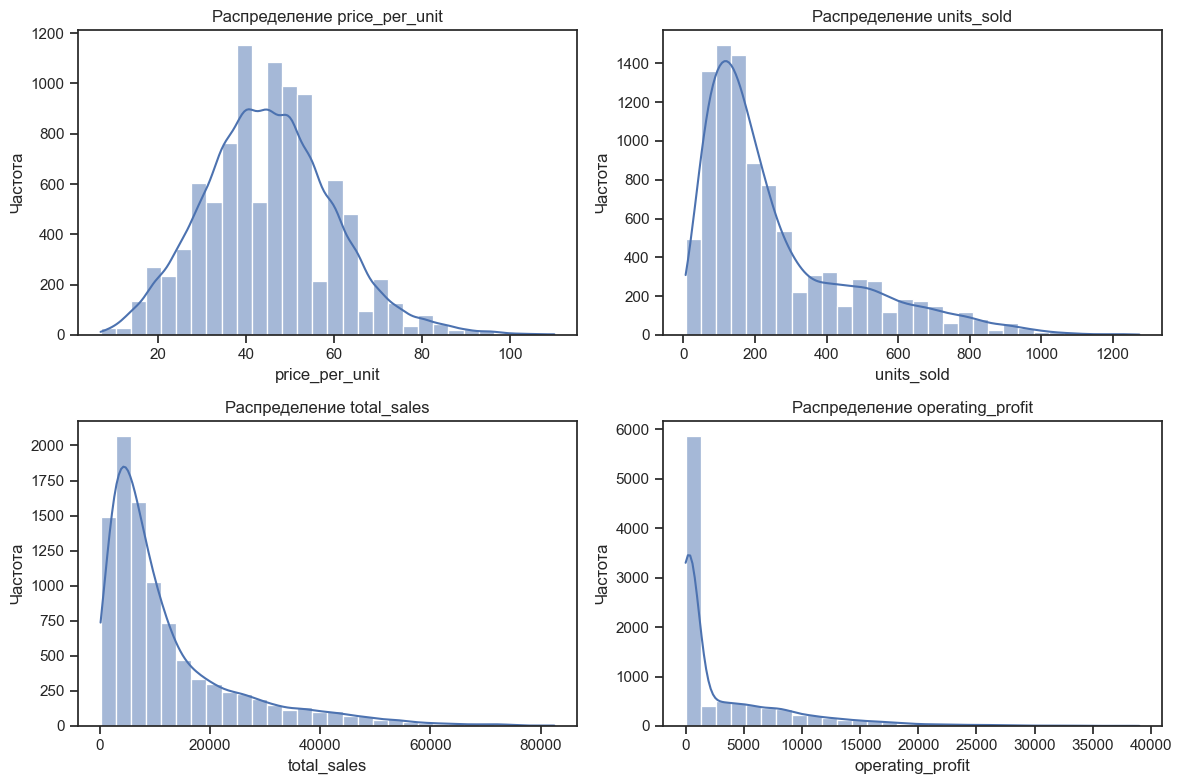

In [14]:
numeric_cols = ['price_per_unit', 'units_sold', 'total_sales', 'operating_profit']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

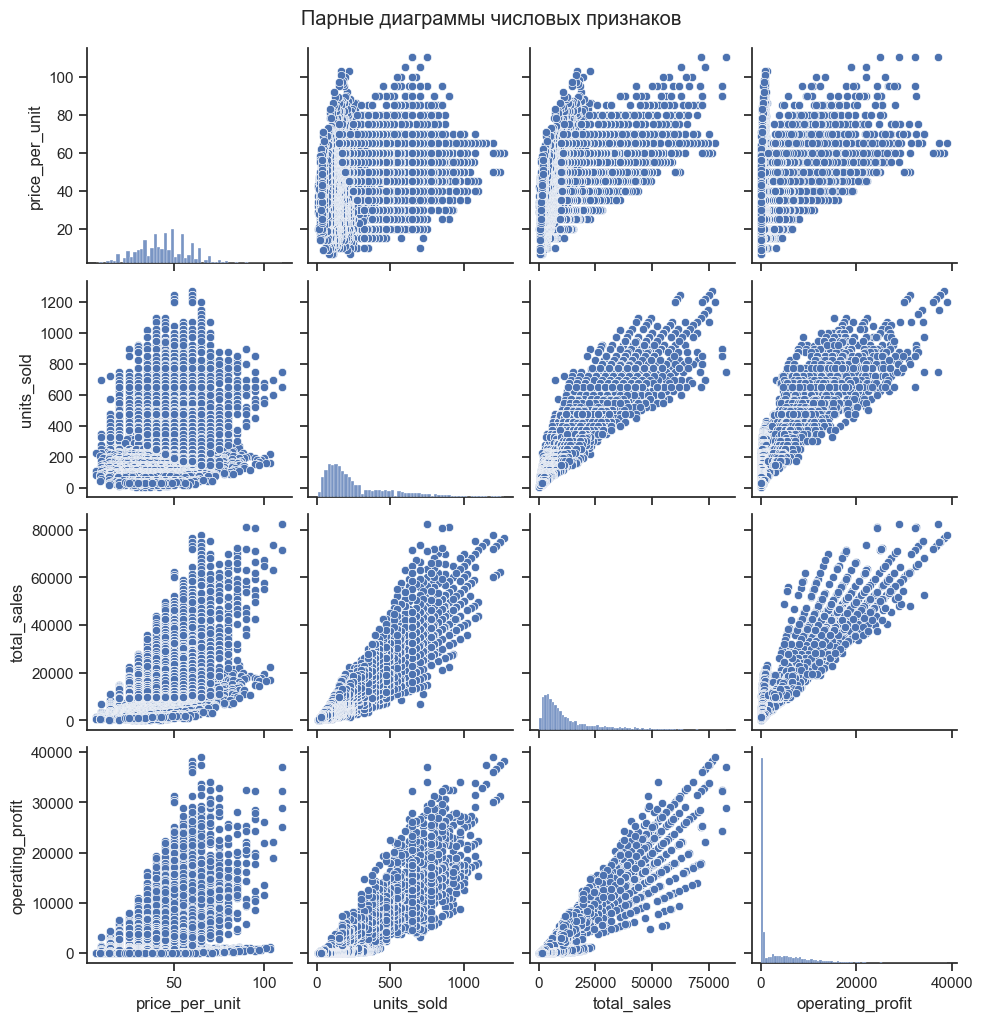

In [16]:
sns.pairplot(data[numeric_cols])
plt.suptitle('Парные диаграммы числовых признаков', y=1.02)
plt.show()

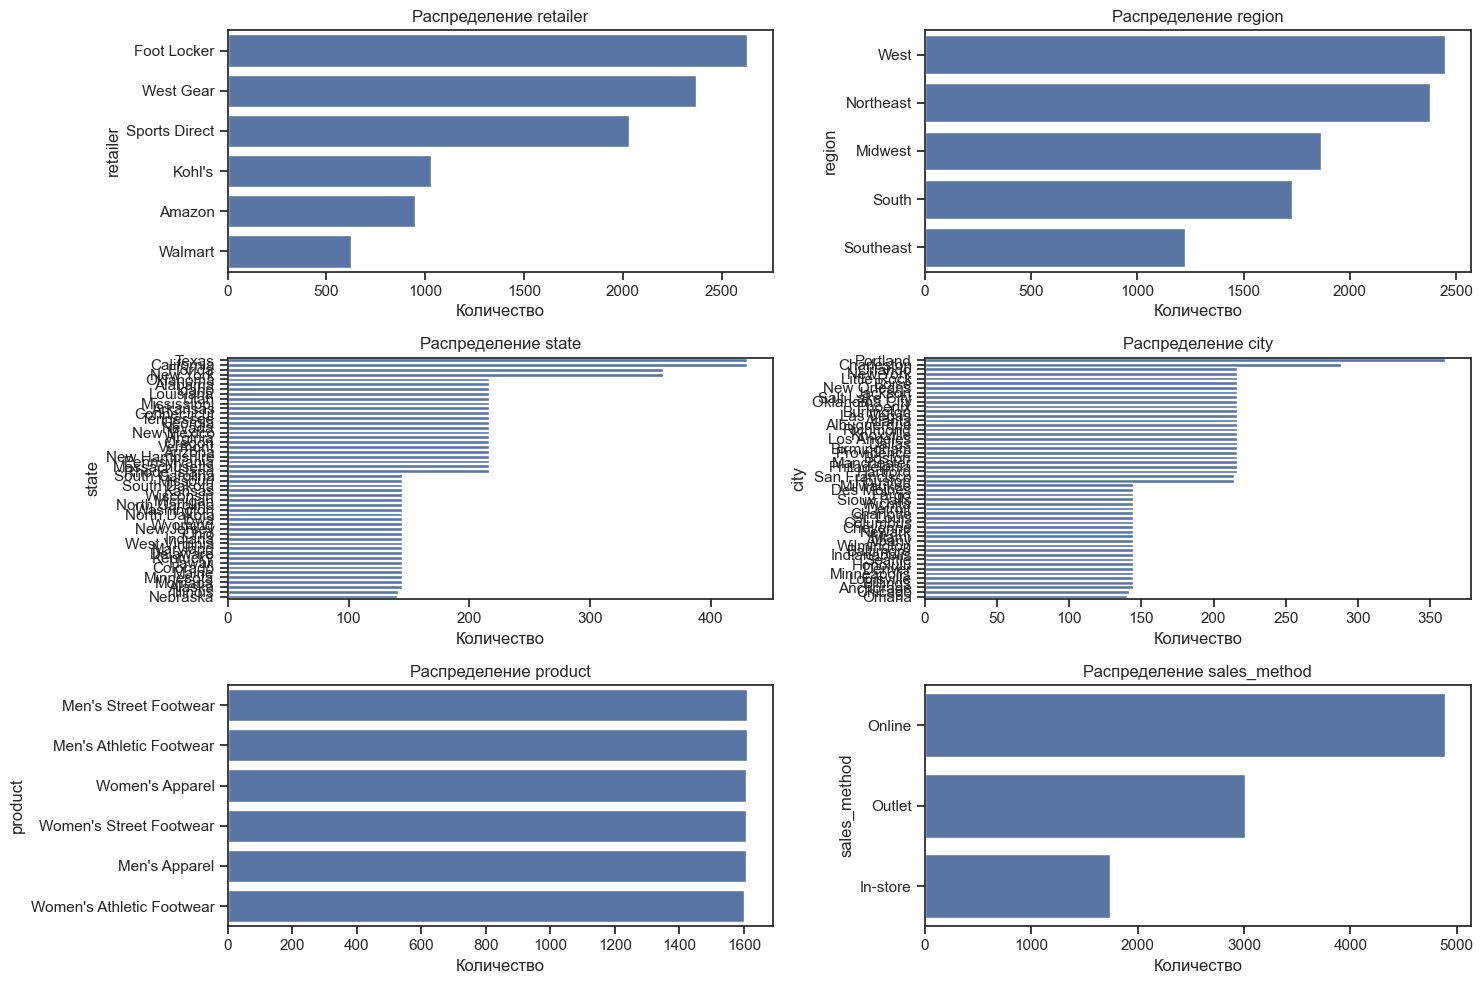

In [17]:
categorical_cols = ['retailer', 'region', 'state', 'city', 'product', 'sales_method']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(y=col, data=data, order=data[col].value_counts().index)
    plt.title(f'Распределение {col}')
    plt.xlabel('Количество')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

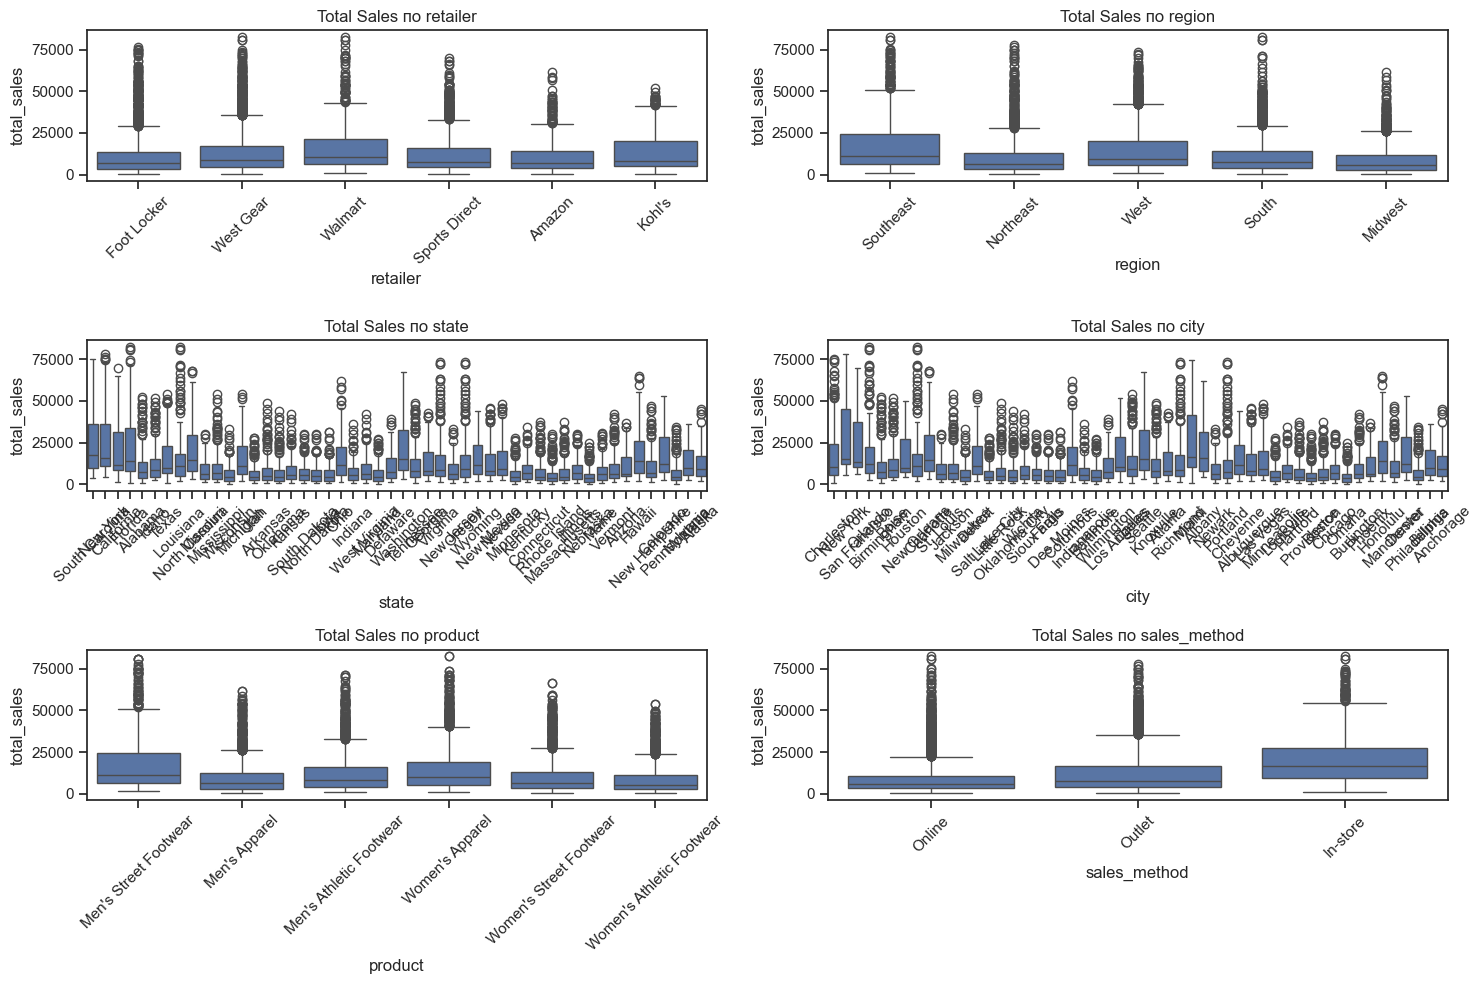

In [18]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=col, y='total_sales', data=data)
    plt.title(f'Total Sales по {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

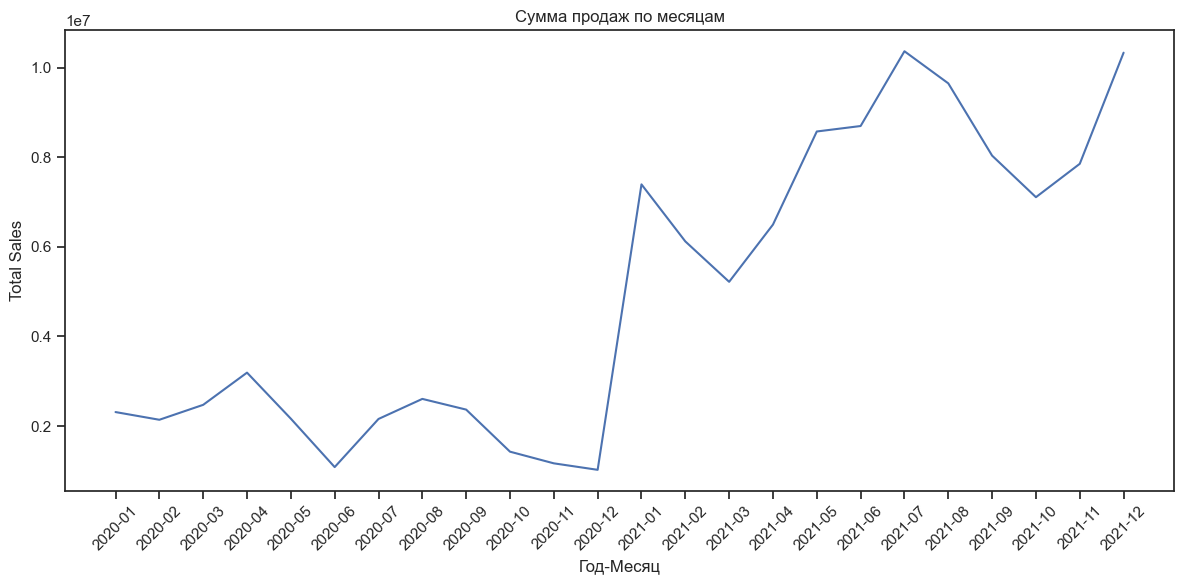

In [20]:
data['year_month'] = data['invoice_date'].dt.to_period('M')
monthly_sales = data.groupby('year_month')['total_sales'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)
plt.figure(figsize=(12, 6))
sns.lineplot(x='year_month', y='total_sales', data=monthly_sales)
plt.title('Сумма продаж по месяцам')
plt.xlabel('Год-Месяц')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

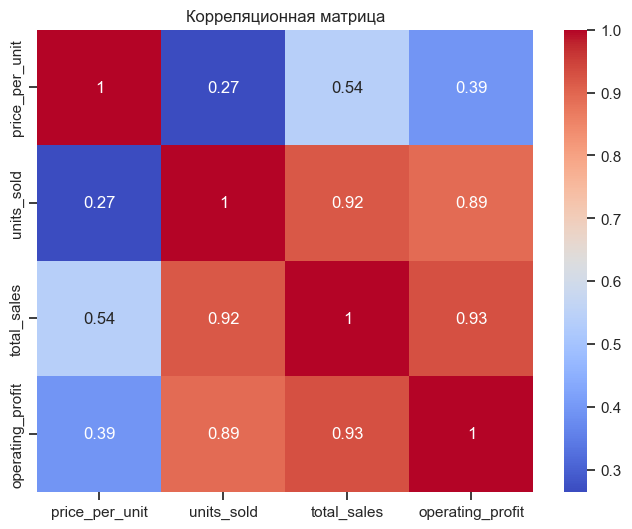

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

In [25]:
data_temp = data.copy()
data_temp['year'] = data_temp['invoice_date'].dt.year
data_temp['month'] = data_temp['invoice_date'].dt.month
data_temp['day'] = data_temp['invoice_date'].dt.day

data_temp = pd.get_dummies(data_temp, columns=['retailer', 'region', 'state', 'city', 'product', 'sales_method'])

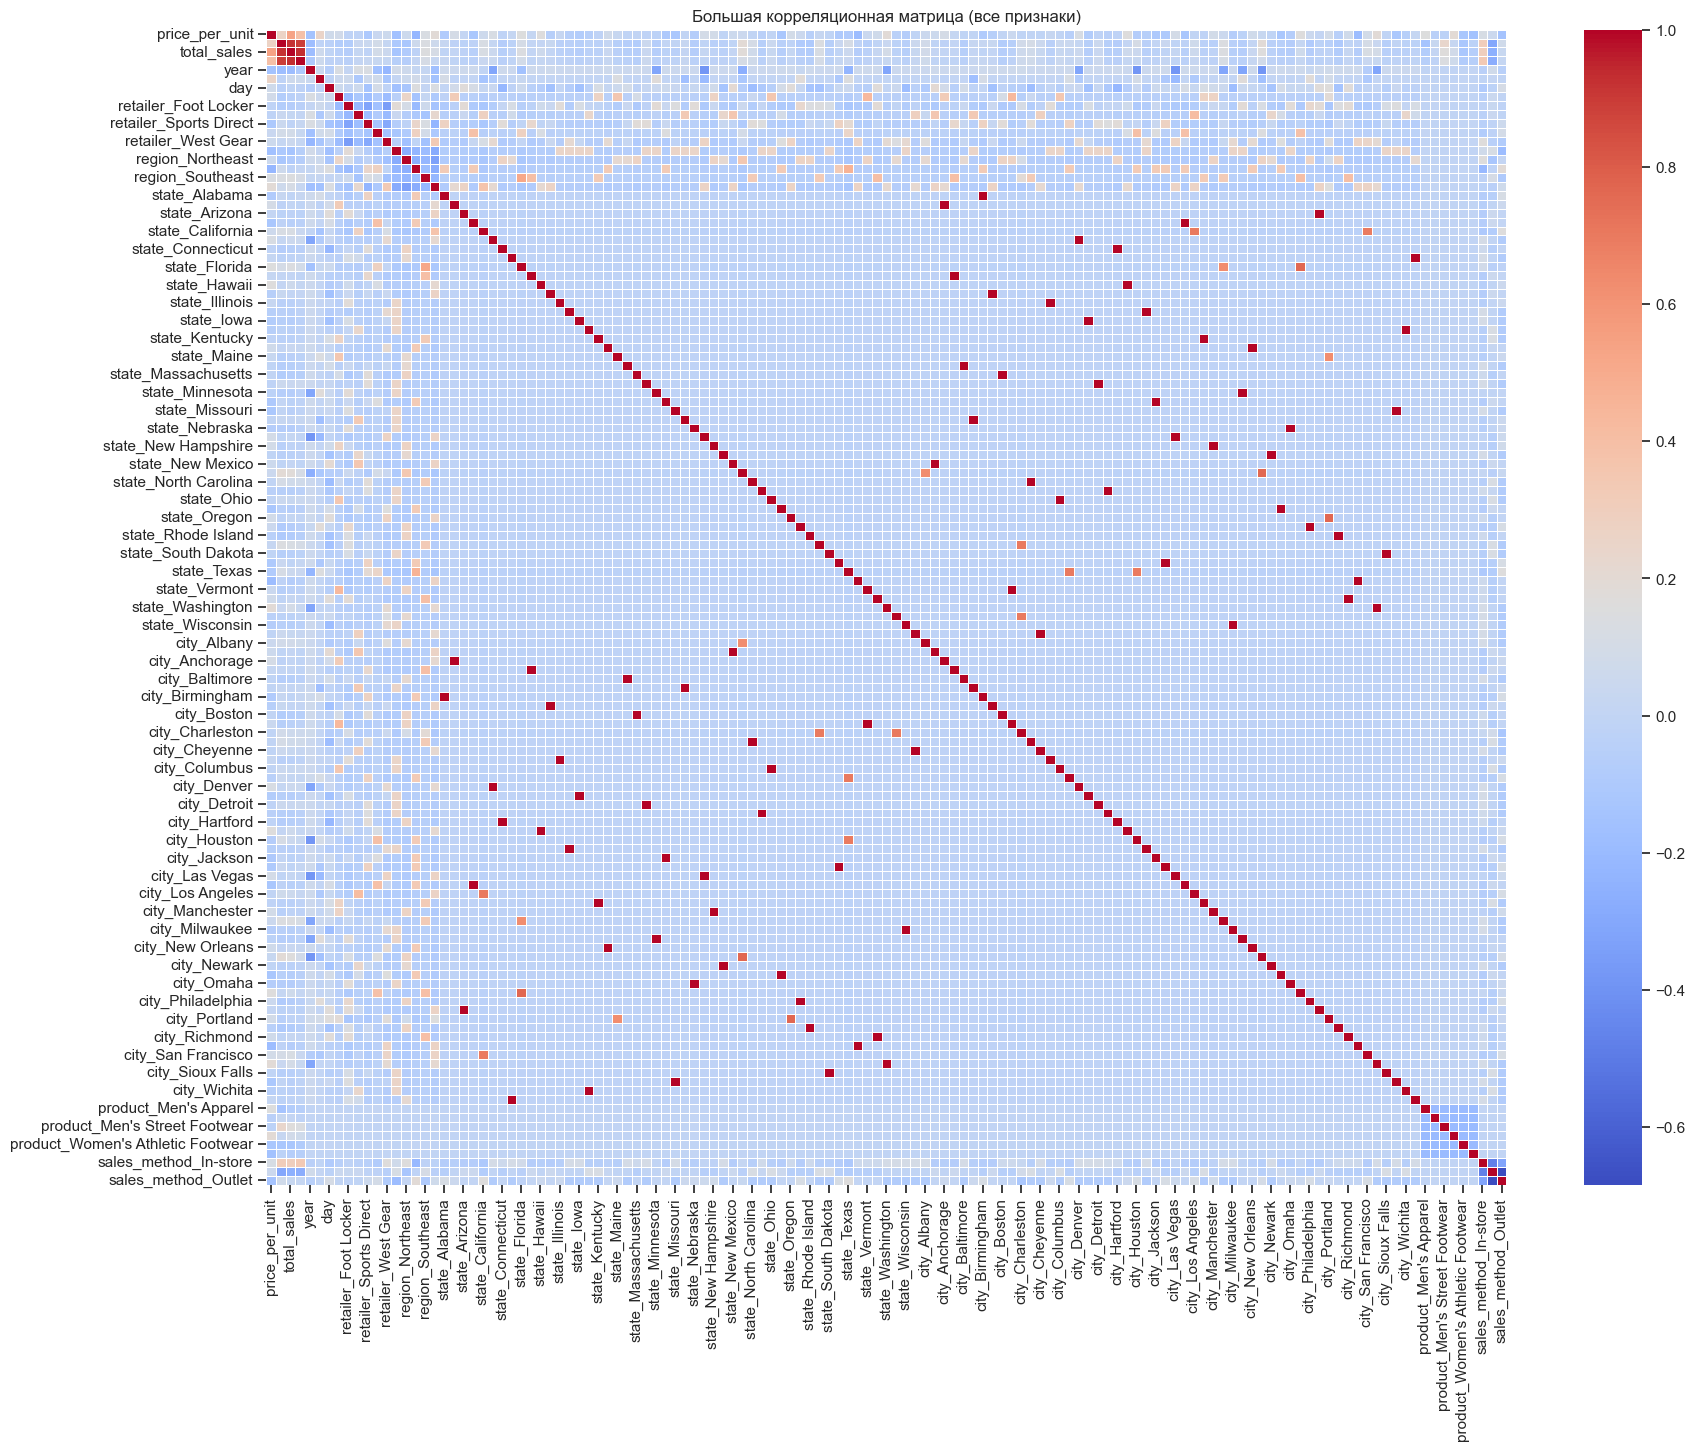

In [26]:
corr_cols = [col for col in data_temp.columns if col not in ['sales_id', 'retailer_id', 'invoice_date', 'year_month']]
plt.figure(figsize=(20, 15))
sns.heatmap(data_temp[corr_cols].corr(), annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Большая корреляционная матрица (все признаки)')
plt.show()

Корреляционный анализ числовых признаков (price_per_unit, units_sold, total_sales, operating_profit) показал, что признаки total_sales и operating_profit имеют высокую корреляцию, так как операционная прибыль напрямую зависит от объема продаж. Это может указывать на мультиколлинеарность, которая может негативно повлиять на линейные модели. Для устранения мультиколлинеарности можно исключить один из коррелирующих признаков или применить методы регуляризации (L1/L2).

Категориальные признаки, такие как region или sales_method, могут влиять на целевую переменную, но их влияние требует дополнительного анализа.

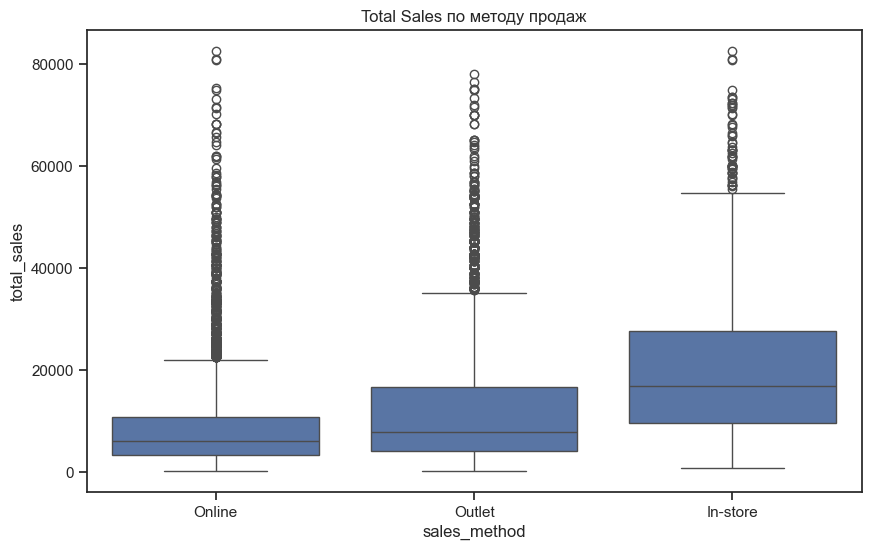

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sales_method', y='total_sales', data=data)
plt.title('Total Sales по методу продаж')
plt.show()

In [28]:
data['year'] = data['invoice_date'].dt.year
data['month'] = data['invoice_date'].dt.month
data['day'] = data['invoice_date'].dt.day

In [29]:
data = data.drop(['sales_id', 'retailer_id', 'invoice_date', 'year_month'], axis=1)

In [30]:
categorical_cols = ['retailer', 'region', 'state', 'city', 'product']
data = pd.get_dummies(data, columns=categorical_cols)

In [31]:
X_reg = data.drop(['total_sales', 'sales_method'], axis=1)
y_reg = data['total_sales']

In [32]:
le = LabelEncoder()
y_clf = le.fit_transform(data['sales_method'])
X_clf = data.drop(['total_sales', 'sales_method'], axis=1)

In [33]:
scaler_reg = MinMaxScaler()
scaler_clf = MinMaxScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)
X_clf_scaled = scaler_clf.fit_transform(X_clf)

In [34]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf_scaled, y_clf, test_size=0.2, random_state=42)

Для задачи классификации были выбраны метрики accuracy, F1 Score и ROC AUC. Эти метрики хорошо подходят для оценки качества моделей, так как:
- Accuracy дает общую оценку правильности предсказаний, но может быть менее информативной при несбалансированных классах.
- F1 Score учитывает баланс между точностью и полнотой, что особенно важно, если классы в задаче классификации несбалансированы (например, если один метод продаж встречается чаще других).
- ROC AUC позволяет оценить способность модели разделять классы, что полезно для задач с вероятностными предсказаниями.

Для задачи регрессии использованы R2 Score, MAE и MSE. Эти метрики обеспечивают комплексную оценку качества предсказаний:
- R2 Score показывает долю объясненной дисперсии, что позволяет оценить, насколько хорошо модель описывает данные.
- MAE измеряет среднюю абсолютную ошибку, что удобно для интерпретации в контексте задачи (например, ошибка в долларах для предсказания total_sales).
- MSE более чувствительна к большим ошибкам, что полезно для выявления выбросов или аномалий в предсказаниях.

In [35]:
reg_models = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

In [49]:
reg_results = []
reg_model_params = {}
print("\nПараметры базовых моделей регрессии:")
for name, model in reg_models.items():
    params = model.get_params()
    reg_model_params[name] = params
    print(f"\n{name}:")
    print(params)
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_test)
    reg_results.append({
        'Model': name,
        'R2': r2_score(y_reg_test, y_pred),
        'MAE': mean_absolute_error(y_reg_test, y_pred),
        'MSE': mean_squared_error(y_reg_test, y_pred)
    })


Параметры базовых моделей регрессии:

Linear Regression:
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

KNN Regressor:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

Decision Tree:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Random Forest:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_

In [37]:
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN Classifier': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [50]:
clf_results = []
clf_model_params = {}
print("\nПараметры базовых моделей классификации:")
for name, model in clf_models.items():
    params = model.get_params()
    clf_model_params[name] = params
    print(f"\n{name}:")
    print(params)
    model.fit(X_clf_train, y_clf_train)
    y_pred = model.predict(X_clf_test)
    y_pred_proba = model.predict_proba(X_clf_test) if hasattr(model, 'predict_proba') else None
    auc = roc_auc_score(label_binarize(y_clf_test, classes=[0,1,2]), y_pred_proba, multi_class='ovr') if y_pred_proba is not None else None
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_clf_test, y_pred),
        'F1 Score': f1_score(y_clf_test, y_pred, average='weighted'),
        'ROC AUC': auc
    })


Параметры базовых моделей классификации:

Logistic Regression:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

KNN Classifier:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

Decision Tree:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Random Forest:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_s

In [52]:
import json
with open('model_parameters.json', 'w', encoding='utf-8') as f:
    json.dump({
        'Regression Models': reg_model_params,
        'Classification Models': clf_model_params
    }, f, indent=4, ensure_ascii=False)

In [39]:
reg_results_df = pd.DataFrame(reg_results)
clf_results_df = pd.DataFrame(clf_results)

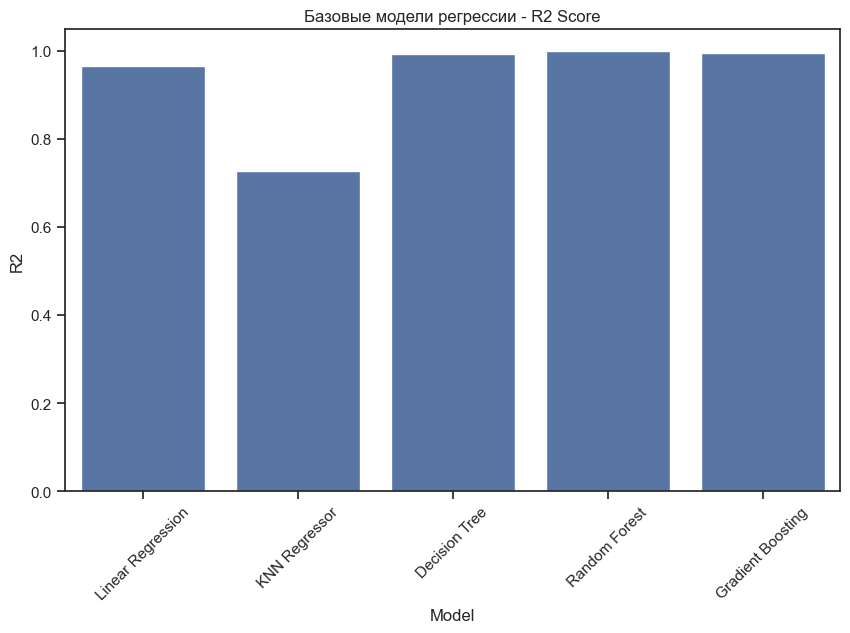

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=reg_results_df)
plt.title('Базовые модели регрессии - R2 Score')
plt.xticks(rotation=45)
plt.show()

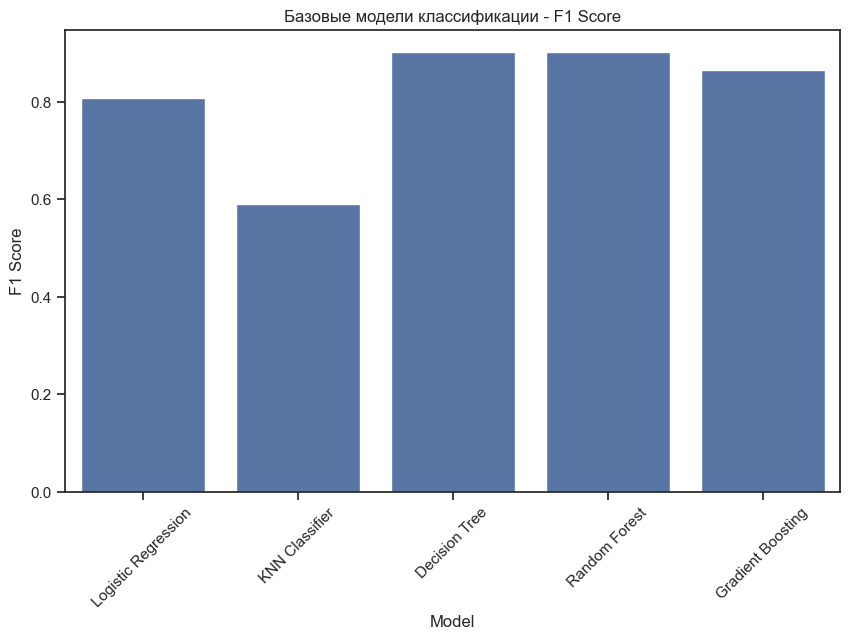

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1 Score', data=clf_results_df)
plt.title('Базовые модели классификации - F1 Score')
plt.xticks(rotation=45)
plt.show()

In [42]:
reg_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
reg_grid = GridSearchCV(RandomForestRegressor(random_state=42), reg_param_grid, cv=5, scoring='r2', n_jobs=-1)
reg_grid.fit(X_reg_train, y_reg_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [53]:
print("\nЛучшие параметры для Random Forest (регрессия):")
print(reg_grid.best_params_)


Лучшие параметры для Random Forest (регрессия):
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


In [43]:
clf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
clf_grid = GridSearchCV(RandomForestClassifier(random_state=42), clf_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
clf_grid.fit(X_clf_train, y_clf_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='f1_weighted')

In [54]:
print("\nЛучшие параметры для Random Forest (классификация):")
print(clf_grid.best_params_)


Лучшие параметры для Random Forest (классификация):
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [55]:
with open('tuned_model_parameters.json', 'w', encoding='utf-8') as f:
    json.dump({
        'Tuned Random Forest (Regression)': reg_grid.best_params_,
        'Tuned Random Forest (Classification)': clf_grid.best_params_
    }, f, indent=4, ensure_ascii=False)

In [44]:
best_reg_model = reg_grid.best_estimator_
y_reg_pred_tuned = best_reg_model.predict(X_reg_test)
reg_tuned_results = {
    'Model': 'Tuned Random Forest',
    'R2': r2_score(y_reg_test, y_reg_pred_tuned),
    'MAE': mean_absolute_error(y_reg_test, y_reg_pred_tuned),
    'MSE': mean_squared_error(y_reg_test, y_reg_pred_tuned)
}

In [45]:
best_clf_model = clf_grid.best_estimator_
y_clf_pred_tuned = best_clf_model.predict(X_clf_test)
y_clf_pred_proba_tuned = best_clf_model.predict_proba(X_clf_test)
clf_tuned_results = {
    'Model': 'Tuned Random Forest',
    'Accuracy': accuracy_score(y_clf_test, y_clf_pred_tuned),
    'F1 Score': f1_score(y_clf_test, y_clf_pred_tuned, average='weighted'),
    'ROC AUC': roc_auc_score(label_binarize(y_clf_test, classes=[0,1,2]), y_clf_pred_proba_tuned, multi_class='ovr')
}

In [46]:
reg_results_df = pd.concat([reg_results_df, pd.DataFrame([reg_tuned_results])], ignore_index=True)
clf_results_df = pd.concat([clf_results_df, pd.DataFrame([clf_tuned_results])], ignore_index=True)

In [58]:
print(reg_results_df)
print()
print(clf_results_df)

                 Model        R2          MAE           MSE
0    Linear Regression  0.966104  1565.064050  4.922594e+06
1        KNN Regressor  0.727951  4244.945643  3.950899e+07
2        Decision Tree  0.993344   304.661826  9.665867e+05
3        Random Forest  0.998079   213.597070  2.790461e+05
4    Gradient Boosting  0.995058   548.232445  7.176916e+05
5  Tuned Random Forest  0.998144   207.820747  2.695670e+05

                 Model  Accuracy  F1 Score   ROC AUC
0  Logistic Regression  0.805498  0.807215  0.923391
1       KNN Classifier  0.590249  0.589973  0.800095
2        Decision Tree  0.901971  0.901990  0.928816
3        Random Forest  0.901971  0.902468  0.980625
4    Gradient Boosting  0.866183  0.865379  0.965557
5  Tuned Random Forest  0.903527  0.904182  0.981090


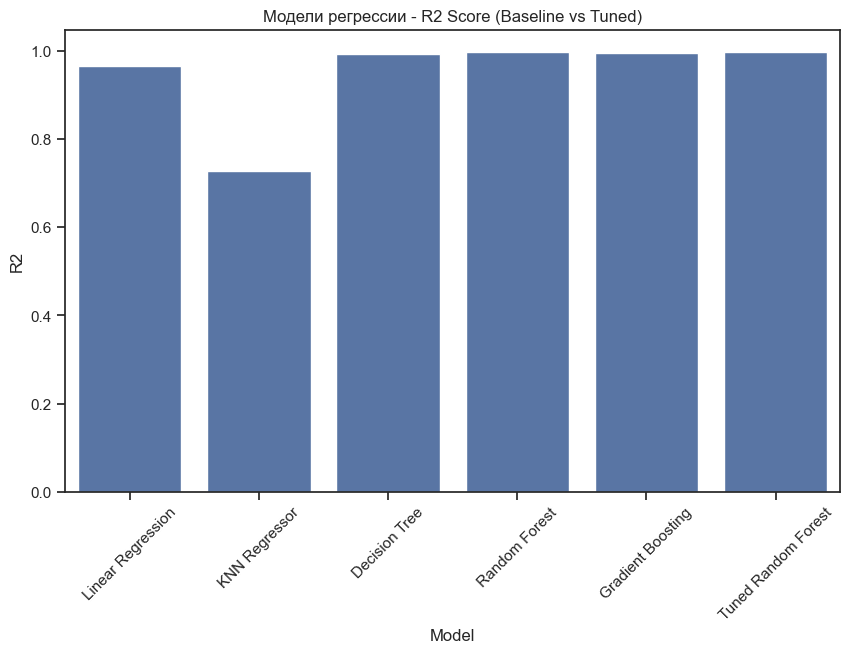

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=reg_results_df)
plt.title('Модели регрессии - R2 Score (Baseline vs Tuned)')
plt.xticks(rotation=45)
plt.show()

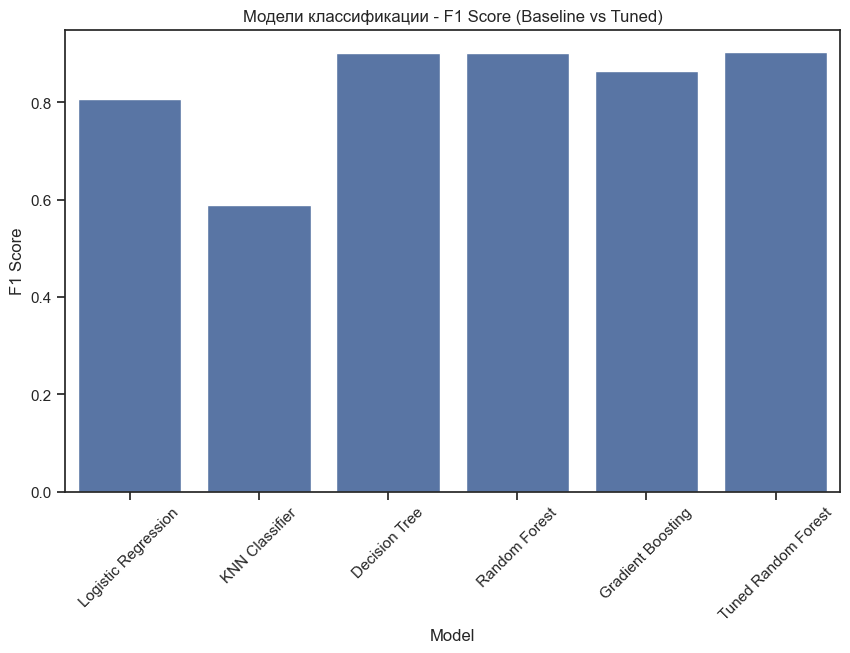

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1 Score', data=clf_results_df)
plt.title('Модели классификации - F1 Score (Baseline vs Tuned)')
plt.xticks(rotation=45)
plt.show()

## Выводы по задаче регрессии

### Общая производительность моделей:
- Все модели регрессии демонстрируют высокую производительность, с R2 от 0.727951 (KNN Regressor) до 0.998144 (Tuned Random Forest). Это указывает на то, что модели в целом хорошо объясняют вариацию целевой переменной (вероятно, total_sales или operating_profit).
- Tuned Random Forest показывает наилучшие результаты с R2 = 0.998144, MAE = 207.82 и MSE = 2.695670e+05, что свидетельствует о высокой точности предсказаний и минимальных ошибках.
- Decision Tree и Gradient Boosting также демонстрируют высокие результаты (R2 = 0.993344 и 0.995058 соответственно), превосходя линейную регрессию и KNN Regressor.

### Сравнение моделей:
- Tuned Random Forest незначительно превосходит baseline Random Forest (R2: 0.998144 против 0.998079, MAE: 207.82 против 213.60, MSE: 2.695670e+05 против 2.790461e+05), что подтверждает эффективность подбора гиперпараметров для улучшения качества предсказаний.
- Linear Regression (R2 = 0.966104, MAE = 1565.06, MSE = 4.922594e+06) показывает хорошие результаты, но значительно уступает ансамблевым моделям (Random Forest, Gradient Boosting) из-за своей неспособности эффективно моделировать нелинейные зависимости в данных.
- KNN Regressor имеет самые низкие показатели (R2 = 0.727951, MAE = 4244.95, MSE = 3.950899e+07), что может быть связано с чувствительностью модели к выбору гиперпараметров (например, числа соседей) и масштабу данных, несмотря на использование MinMaxScaler.

### Анализ метрик:
- Высокий R2 у ансамблевых моделей (Random Forest, Gradient Boosting) указывает на то, что они объясняют почти всю вариацию целевой переменной, что делает их предпочтительными для прогнозирования продаж или прибыли.
- Низкие значения MAE и MSE у Tuned Random Forest и Decision Tree (MAE = 207.82 и 304.66 соответственно) показывают, что эти модели обеспечивают точные предсказания с минимальными отклонениями от фактических значений.
- Высокие значения MAE и MSE у KNN Regressor указывают на значительные ошибки в предсказаниях, что делает эту модель менее подходящей для данной задачи.

### Вывод по регрессии:
- Ансамблевые модели, особенно Tuned Random Forest, являются наиболее подходящими для предсказания объемов продаж или операционной прибыли в наборе данных Adidas US Sales. Подбор гиперпараметров позволил добиться минимальных улучшений в Random Forest, что подчеркивает важность оптимизации для достижения наилучших результатов.
- Линейная регрессия может быть использована в качестве простого baseline-решения, но ее производительность ограничена из-за нелинейных зависимостей в данных.
- KNN Regressor показал наихудшие результаты, что может быть связано с необходимостью более тщательной настройки гиперпараметров или неподходящей структурой данных для этой модели.

## Выводы по задаче классификации

### Общая производительность моделей:
- Все модели классификации демонстрируют приемлемую производительность, с Accuracy от 0.590249 (KNN Classifier) до 0.903527 (Tuned Random Forest) и F1 Score от 0.589973 (KNN Classifier) до 0.904182 (Tuned Random Forest).
- Tuned Random Forest снова показывает лучшие результаты с Accuracy = 0.903527, F1 Score = 0.904182 и ROC AUC = 0.981090, что указывает на высокую способность модели правильно классифицировать данные (например, методы продаж или категории продуктов).
- Decision Tree и Gradient Boosting также демонстрируют высокие результаты (Accuracy = 0.901971 и 0.866183, F1 Score = 0.901990 и 0.865379 соответственно), превосходя логистическую регрессию и KNN Classifier.

### Сравнение моделей:
- Tuned Random Forest незначительно превосходит baseline Random Forest (Accuracy: 0.903527 против 0.901971, F1 Score: 0.904182 против 0.902468, ROC AUC: 0.981090 против 0.980625), что подтверждает положительное влияние подбора гиперпараметров.
- Logistic Regression (Accuracy = 0.805498, F1 Score = 0.807215, ROC AUC = 0.923391) показывает хорошие результаты для линейной модели, но уступает ансамблевым моделям из-за ограниченной способности улавливать нелинейные зависимости.
- KNN Classifier имеет самые низкие показатели (Accuracy = 0.590249, F1 Score = 0.589973, ROC AUC = 0.800095), что может быть связано с несбалансированностью классов или недостаточной настройкой гиперпараметров.

### Анализ метрик:
- Высокие значения ROC AUC у Tuned Random Forest и Gradient Boosting (0.981090 и 0.965557 соответственно) указывают на отличную способность этих моделей разделять классы, что особенно важно для задач с вероятностными предсказаниями.
- F1 Score, учитывающий баланс между точностью и полнотой, показывает, что ансамблевые модели (Random Forest, Gradient Boosting) наиболее устойчивы к возможной несбалансированности классов в данных.
- Низкие значения Accuracy и F1 Score у KNN Classifier могут указывать на проблемы с выбором числа соседей или чувствительностью модели к масштабу данных, несмотря на предобработку.

### Вывод по классификации:
- Ансамблевые модели, особенно Tuned Random Forest, являются наиболее эффективными для задачи классификации в наборе данных Adidas US Sales. Высокие значения Accuracy, F1 Score и ROC AUC подтверждают их пригодность для предсказания категорий, таких как методы продаж или типы продуктов.
- Логистическая регрессия демонстрирует приемлемые результаты и может использоваться как baseline, но ее производительность ограничена из-за нелинейных зависимостей в данных.
- KNN Classifier показал наихудшие результаты, что указывает на необходимость более тщательной настройки гиперпараметров или пересмотра подхода к предобработке данных.

## Общие выводы

### Сравнение задач регрессии и классификации:
- Для задачи регрессии модели достигли более высоких метрик (R2 близок к 1 у Tuned Random Forest), что указывает на более предсказуемую природу целевой переменной (например, total_sales или operating_profit). Это может быть связано с сильной корреляцией между числовыми признаками, такими как price_per_unit и units_sold, и целевой переменной.
- В задаче классификации метрики ниже (Accuracy и F1 Score около 0.9 у лучших моделей), что может быть связано с несбалансированностью классов или сложностью разделения категорий (например, методов продаж).

### Эффективность подбора гиперпараметров:
- Подбор гиперпараметров с использованием GridSearchCV привел к улучшению качества моделей как в задаче регрессии, так и в классификации. Наибольший эффект наблюдается у Random Forest, где Tuned версия показала лучшие результаты по всем метрикам.
- Это подчеркивает важность оптимизации гиперпараметров, особенно для ансамблевых моделей, которые имеют множество параметров (например, n_estimators, max_depth, learning_rate).